In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import contextily as ctx
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from catboost import CatBoostClassifier, Pool
import shap

In [75]:
df = pd.read_excel('df_all_features.xlsx')
df['pois_5ped'] = df[['beauty_count_5ped', 'cafe_count_5ped', 'coffee_count_5ped', 'supermarkets4rich_count_5ped']].sum(axis=1)
df['reviews_5ped'] = df[['beauty_reviews_sum_5ped', 'cafe_reviews_sum_5ped', 'coffee_reviews_sum_5ped', 'supermarkets4rich_reviews_sum_5ped']].sum(axis=1)

df.shape

(4996, 335)

In [76]:
df['is_closed'].value_counts()

is_closed
0    3483
1    1513
Name: count, dtype: int64

In [77]:
lst = [
'lat',
'lon',
'subs_month',
'subs_year',
'energy_class_mean_15ped',
'energy_class_mean_15drive',
'metro',
'INHAB_count_15ped',
'INHAB_count_15drive',
'rent_2026_price_per_m2_mean_15ped',
'rent_2026_price_per_m2_mean_15drive',
'competitors_count_15drive',
'competitors_count_15ped',
'parks_count_15ped',
'parks_reviews_sum_15ped',
'molls_count_15ped',
'molls_reviews_sum_5ped',
'pois_5ped',
'reviews_5ped',
'buy_2026_price_per_m2_mean_15ped',
'incomes_2025_avg_hcs_cost_pop_mean_15ped',
'buy_2021_2026_abs_15ped',
'buy_2021_2026_pct_15ped',
'net',
'bus_count_15ped',
'workplaces_count_15ped',
'urls_true',
'content_studio',
'content_complex_castle',
'content_pilates',
'content_trainings',
'content_class_area',
'is_closed'
]
df=df[lst].copy()


In [78]:
# 1. Подготовка данных
X = df.drop('is_closed', axis=1)
y = df['is_closed']

# Оставляем lat и lon! Заменяем inf на NaN (CatBoost с ними справится)
X = X.replace([np.inf, -np.inf], np.nan)

# Укажи здесь названия колонок с текстом/категориями, если они есть. 
# Например: cat_features = ['region', 'building_type']
cat_features = [] # Оставь пустым, если все данные числовые

# 2. Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test_coord = X_test.copy()
X_train = X_train.drop(['lat','lon'], axis=1)
X_test = X_test.drop(['lat','lon'], axis=1)

# 3. Вычисление веса для балансировки классов
# Считаем отношение: (Количество успешных клубов) / (Количество закрытых)
class_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Вес миноритарного класса (scale_pos_weight): {class_weight:.2f}")

# 4. Настройка и обучение модели
model = CatBoostClassifier(
    iterations=1000,              # Максимальное количество деревьев
    learning_rate=0.05,           # Шаг обучения (чем меньше, тем точнее, но дольше)
    depth=6,                      # Глубина деревьев (6-8 оптимально для CatBoost)
    scale_pos_weight=class_weight,# Штраф за пропуск закрытия (класс 1)
    eval_metric='AUC',            # Оптимизируем под ROC-AUC
    random_seed=42,
    od_type='Iter',
    od_wait=50,                   # Ранняя остановка: если 50 шагов метрика не растет - стоп
    verbose=100                   # Выводить лог каждые 100 шагов
)

# Обучаем, передавая тестовую выборку для контроля переобучения
model.fit(
    X_train, y_train, 
    eval_set=(X_test, y_test), 
    cat_features=cat_features,
    use_best_model=True
)

# 5. Оценка и Бизнес-подбор порога
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print(f"Базовый ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*40)

# Функция для оценки с точки зрения бизнеса
def evaluate_business_threshold(y_true, probabilities, threshold):
    preds = (probabilities >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    
    TN = cm[0, 0] # Правильно предсказанный успех (0)
    FP = cm[0, 1] # Ошибочно забраковано (0 назвали 1)
    FN = cm[1, 0] # КАТАСТРОФА: Ошибочно одобрено (1 назвали 0)
    TP = cm[1, 1] # Правильно предсказанное закрытие (1)
    
    precision_0 = TN / (TN + FN) if (TN + FN) > 0 else 0 # Надежность инвестиции
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0    # % найденных хороших мест
    
    print(f"\nПорог отсечения: {threshold:.2f}")
    print(f"Надежность одобренных локаций (Precision 0): {precision_0*100:.1f}%")
    print(f"Доля одобренных хороших локаций (Recall 0): {recall_0*100:.1f}%")
    print(f"Количество фатальных ошибок (ложных одобрений): {FN} из {len(y_true)}")

# Смотрим разные сценарии:
# 0.40 - Консервативный инвестор (отвергает всё подозрительное)
# 0.50 - Баланс
# 0.60 - Рискованный инвестор (одобряет больше мест, но выше риск банкротства)
for t in [0.40, 0.50, 0.60]:
    evaluate_business_threshold(y_test, y_pred_proba, t)

# 6. Важность признаков (Что влияет на выживаемость?)
feature_importance = model.get_feature_importance(prettified=True)
print("\n=== Топ-10 факторов выживаемости фитнес-клуба ===")
print(feature_importance.head(60))

Вес миноритарного класса (scale_pos_weight): 2.30
0:	test: 0.7317405	best: 0.7317405 (0)	total: 7.52ms	remaining: 7.52s
100:	test: 0.7678121	best: 0.7693415 (90)	total: 1.11s	remaining: 9.87s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7693414966
bestIteration = 90

Shrink model to first 91 iterations.

Базовый ROC-AUC: 0.7693

Порог отсечения: 0.40
Надежность одобренных локаций (Precision 0): 90.2%
Доля одобренных хороших локаций (Recall 0): 51.6%
Количество фатальных ошибок (ложных одобрений): 39 из 1000

Порог отсечения: 0.50
Надежность одобренных локаций (Precision 0): 88.0%
Доля одобренных хороших локаций (Recall 0): 61.1%
Количество фатальных ошибок (ложных одобрений): 58 из 1000

Порог отсечения: 0.60
Надежность одобренных локаций (Precision 0): 80.7%
Доля одобренных хороших локаций (Recall 0): 80.2%
Количество фатальных ошибок (ложных одобрений): 134 из 1000

=== Топ-10 факторов выживаемости фитнес-клуба ===
                                  Feature Id  

[LightGBM] [Info] Number of positive: 1210, number of negative: 2786
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3901
[LightGBM] [Info] Number of data points in the train set: 3996, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.302803 -> initscore=-0.833987
[LightGBM] [Info] Start training from score -0.833987


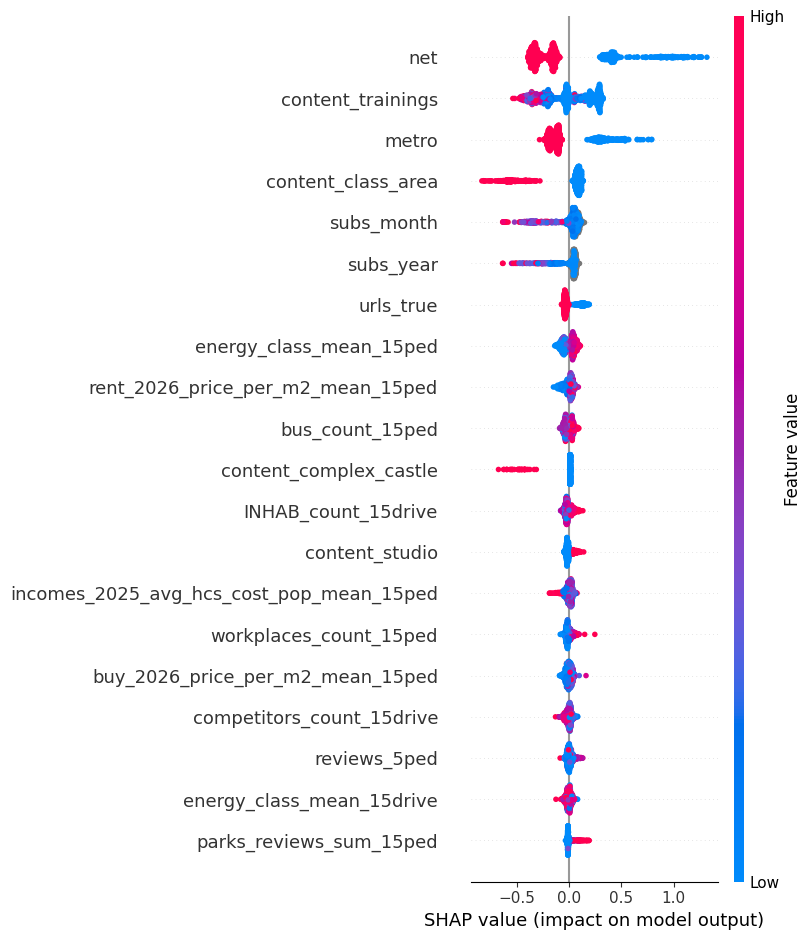

In [83]:
# --- 2. АНАЛИЗ ВАЖНОСТИ ЧЕРЕЗ SHAP ---
# Теперь lgb_model существует, и SHAP сработает без ошибок
explainer = shap.TreeExplainer(model)

# Считаем SHAP-значения 
shap_values = explainer.shap_values(X_test)

# Рисуем график (смотрим влияние на класс 1)
shap.summary_plot(shap_values, X_test, plot_type="dot",layered_violin_max_num_bins=40)

In [ ]:
all_data = X_test.copy()
all_data['is_closed'] = y_pred

In [82]:
warnings.filterwarnings('ignore')

# 1. Создаем папку 'maps' во избежание проблем с кодировкой в Windows
os.makedirs('maps', exist_ok=True)

# Загружаем районы и СРАЗУ переводим в Web Mercator (EPSG:3857)
districts = gpd.read_file('Moscow.geojson').to_crs(epsg=3857)

# --- ПОДГОТОВКА ДАННЫХ ДЛЯ ОТРИСОВКИ (ПРОГНОЗ) ---
all_data = X_test_coord.copy()
all_data['is_closed'] = y_pred

# ====================================================================
# ВАЖНО: СТРОИМ ГРАНИЦЫ И СЕТКУ ПО ИСХОДНОМУ 'df', А НЕ ПО 'X_test_coord'
# ====================================================================
global_gdf_original = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

minx, miny, maxx, maxy = global_gdf_original.total_bounds
x_padding = (maxx - minx) * 0.05
y_padding = (maxy - miny) * 0.05

X_MIN_BOUND = minx - x_padding
X_MAX_BOUND = maxx + x_padding
Y_MIN_BOUND = miny - y_padding
Y_MAX_BOUND_INITIAL = maxy + y_padding

# --- ИСПРАВЛЕНИЕ ИСКАЖЕНИЯ ГЕКСАГОНОВ ---
GRID_SIZE_X = 16
dx = (X_MAX_BOUND - X_MIN_BOUND) / GRID_SIZE_X
dy = dx * np.sqrt(3)  # Математическая пропорция правильного гексагона

# Вычисляем целое количество ячеек по Y и корректируем верхнюю границу
GRID_SIZE_Y = int(np.ceil((Y_MAX_BOUND_INITIAL - Y_MIN_BOUND) / dy))
Y_MAX_BOUND = Y_MIN_BOUND + GRID_SIZE_Y * dy  

EXTENT_BOX = (X_MIN_BOUND, X_MAX_BOUND, Y_MIN_BOUND, Y_MAX_BOUND)
GRID_TUPLE = (GRID_SIZE_X, GRID_SIZE_Y)


def create_hexbin_map(data_subset, districts_gdf, title, filename):
    """
    Функция для генерации и сохранения hexbin-карты доли закрытий с границами районов.
    """
    # 1. Подготовка геоданных
    gdf = gpd.GeoDataFrame(
        data_subset, 
        geometry=gpd.points_from_xy(data_subset['lon'], data_subset['lat']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    # 2. Настройка холста
    fig, ax = plt.subplots(1, 1, figsize=(15, 12), facecolor='#ffffff')
    ax.set_axis_off()
    ax.set_aspect('equal')

    # 3. --- ГЕКСАГОНАЛЬНАЯ СЕТКА (HEXBIN) ---
    x = gdf.geometry.x
    y = gdf.geometry.y
    c_values = gdf['is_closed'] 

    # Отрисовка сот (zorder=5, чтобы быть над базовой картой, но под районами)
    hb = ax.hexbin(
        x, y, 
        C=c_values, 
        reduce_C_function=lambda val: np.mean(val) * 100, 
        gridsize=GRID_TUPLE,      # <--- ИСПОЛЬЗУЕМ КОРТЕЖ СЕТКИ
        cmap='Reds',     
        mincnt=3,          
        alpha=0.85,        
        edgecolors='white',
        linewidths=0.5,
        extent=EXTENT_BOX,
        vmin=0,           # <--- ЖЕСТКАЯ ПРИВЯЗКА МИНИМУМА К 0%
        vmax=100,         # <--- ЖЕСТКАЯ ПРИВЯЗКА МАКСИМУМА К 100%
        zorder=5
    )

    # 4. --- ДОБАВЛЯЕМ ГРАНИЦЫ РАЙОНОВ ---
    districts_gdf.plot(
        ax=ax,
        facecolor='none',          # Без заливки (прозрачно)
        edgecolor='#2c3e50',       # Темно-синий/серый цвет границ
        linewidth=0.6,             # Тонкая линия
        alpha=0.6,                 # Полупрозрачность
        zorder=6
    )

    # 5. Добавляем светлую подложку улиц
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8, zoom='auto')
    except Exception as e:
        print(f"Не удалось загрузить базовую карту: {e}")

    # Применяем глобальные рамки к осям В КОНЦЕ
    ax.set_xlim(X_MIN_BOUND, X_MAX_BOUND)
    ax.set_ylim(Y_MIN_BOUND, Y_MAX_BOUND)

    # 6. Оформление карты
    cb = fig.colorbar(hb, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label('Доля закрытых объектов (%)', fontsize=12, fontweight='bold', color='#333333', rotation=270, labelpad=20)
    cb.ax.tick_params(labelsize=10)

    # Заголовок
    bbox_props_title = dict(boxstyle="round,pad=0.5", fc="#333333", ec="none", alpha=0.85)
    x_title = minx + (maxx - minx) * 0.5 
    y_title = maxy + y_padding 

    ax.text(x_title, y_title, title, 
            fontsize=16, fontweight='bold', color='white', 
            ha='center', va='bottom', bbox=bbox_props_title, zorder=10)

    plt.tight_layout()

    # 7. Сохраняем результат в английскую папку
    filepath = os.path.join('maps', filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.close()

    print(f"Карта сохранена: {filepath}")


# ==========================================
# 2. ФИЛЬТРАЦИЯ ДАННЫХ И СОЗДАНИЕ КАРТ
# ==========================================

# Карта для СТУДИЙ
studios_data = all_data[(all_data['content_studio'] == 1)].copy()
create_hexbin_map(
    data_subset=studios_data, 
    districts_gdf=districts, 
    title="Прогноз: доля закрытий фитнес-студий", 
    filename='hexbin_closure_rate_studios_pred.png'
)

# Карта для КЛУБОВ
clubs_data = all_data[(all_data['content_class_area'] == 1)].copy()
create_hexbin_map(
    data_subset=clubs_data, 
    districts_gdf=districts, 
    title="Прогноз: доля закрытий фитнес-клубов", 
    filename='hexbin_closure_rate_clubs_pred.png'
)

# Карта для СЕТЕВЫХ ОБЪЕКТОВ
net_data = all_data[(all_data['net'] == 1)].copy()
create_hexbin_map(
    data_subset=net_data, 
    districts_gdf=districts, 
    title="Прогноз: доля закрытий сетевых объектов", 
    filename='hexbin_closure_rate_net_pred.png'
)

# Карта всех ОБЪЕКТОВ
all_fitness_data = all_data.copy()
create_hexbin_map(
    data_subset=all_fitness_data, 
    districts_gdf=districts, 
    title="Прогноз: доля закрытий фитнес-объектов", 
    filename='hexbin_closure_rate_all_pred.png'
)

Карта сохранена: maps\hexbin_closure_rate_studios_pred.png
Карта сохранена: maps\hexbin_closure_rate_clubs_pred.png
Карта сохранена: maps\hexbin_closure_rate_net_pred.png
Карта сохранена: maps\hexbin_closure_rate_all_pred.png


In [81]:
warnings.filterwarnings('ignore')

# 1. Создаем папку 'Карты'
os.makedirs('Карты', exist_ok=True)
os.makedirs('stats', exist_ok=True)
# Было: os.makedirs('Карты', exist_ok=True)
os.makedirs('maps', exist_ok=True) 
os.makedirs('stats', exist_ok=True)

# Словарь цветов для матрицы 3x3 (X - количество, Y - процент закрытий)
BIVARIATE_COLORS = {
    '1-1': '#e8e8e8', '2-1': '#ace4e4', '3-1': '#5ac8c8',  # Низкий % закрытий
    '1-2': '#dfb0d6', '2-2': '#a5add3', '3-2': '#5698b9',  # Средний % закрытий
    '1-3': '#be64ac', '2-3': '#8c62aa', '3-3': '#3b4994'   # Высокий % закрытий
}

# --- ПОДГОТОВКА ДАННЫХ ДЛЯ ОТРИСОВКИ (ПРОГНОЗ) ---
all_data = X_test_coord.copy()
all_data['is_closed'] = y_pred

# ====================================================================
# ВАЖНО: СТРОИМ ГРАНИЦЫ И СЕТКУ ПО ИСХОДНОМУ 'df', А НЕ ПО 'X_test_coord'
# ====================================================================
global_gdf_original = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

minx, miny, maxx, maxy = global_gdf_original.total_bounds
x_padding = (maxx - minx) * 0.05
y_padding = (maxy - miny) * 0.05

X_MIN_BOUND = minx - x_padding
X_MAX_BOUND = maxx + x_padding
Y_MIN_BOUND = miny - y_padding
Y_MAX_BOUND_INITIAL = maxy + y_padding

# --- ИСПРАВЛЕНИЕ ИСКАЖЕНИЯ ГЕКСАГОНОВ ---
GRID_SIZE_X = 16
dx = (X_MAX_BOUND - X_MIN_BOUND) / GRID_SIZE_X
dy = dx * np.sqrt(3)  # Математическая пропорция правильного гексагона

# Вычисляем целое количество ячеек по Y и корректируем верхнюю границу
GRID_SIZE_Y = int(np.ceil((Y_MAX_BOUND_INITIAL - Y_MIN_BOUND) / dy))
Y_MAX_BOUND = Y_MIN_BOUND + GRID_SIZE_Y * dy  

EXTENT_BOX = (X_MIN_BOUND, X_MAX_BOUND, Y_MIN_BOUND, Y_MAX_BOUND)
GRID_TUPLE = (GRID_SIZE_X, GRID_SIZE_Y)


def get_terciles(series):
    """Безопасное разбиение на 3 группы"""
    if len(series) < 3:
        return pd.Series(['1'] * len(series))
    return pd.qcut(series.rank(method='first'), 3, labels=['1', '2', '3']).astype(str)


def create_bivariate_hexbin(data_subset, districts_gdf, title, filename):
    # Подготовка геоданных
    gdf = gpd.GeoDataFrame(
        data_subset, 
        geometry=gpd.points_from_xy(data_subset['lon'], data_subset['lat']),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    fig, ax = plt.subplots(1, 1, figsize=(15, 12), facecolor='#ffffff')
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_xlim(X_MIN_BOUND, X_MAX_BOUND)
    ax.set_ylim(Y_MIN_BOUND, Y_MAX_BOUND)

    x = gdf.geometry.x
    y = gdf.geometry.y
    is_closed = gdf['is_closed']
    
    MIN_CLUBS_IN_HEX = 3

    # --- 1. СТРОИМ ОСНОВНУЮ СЕТКУ ---
    # ЗДЕСЬ ИСПОЛЬЗУЕМ GRID_TUPLE вместо GRID_SIZE
    hb = ax.hexbin(x, y, gridsize=GRID_TUPLE, extent=EXTENT_BOX, mincnt=MIN_CLUBS_IN_HEX, 
                   edgecolors='white', linewidths=0.5, zorder=5)
    counts = hb.get_array()
    
    if len(counts) == 0:
        print(f"Нет данных для отрисовки карты: {title}")
        plt.close()
        return

    # --- 2. СЧИТАЕМ ЗАКРЫТИЯ (НЕВИДИМЫЙ СЛОЙ) ---
    # ЗДЕСЬ ТОЖЕ ИСПОЛЬЗУЕМ GRID_TUPLE
    hb_closed = ax.hexbin(x, y, C=is_closed, reduce_C_function=np.sum, 
                          gridsize=GRID_TUPLE, extent=EXTENT_BOX, mincnt=MIN_CLUBS_IN_HEX, visible=False)
    closed_sums = hb_closed.get_array()

    # --- 3. БИВАРИАНТНАЯ ЛОГИКА ---
    shares = (closed_sums / counts) * 100
    qty_class = get_terciles(pd.Series(counts))
    share_class = get_terciles(pd.Series(shares))
    
    biv_keys = qty_class + '-' + share_class
    
    # Формируем массив цветов
    rgba_colors = np.array([mcolors.to_rgba(BIVARIATE_COLORS[k], alpha=0.85) for k in biv_keys])

    # --- ВАЖНОЕ ИСПРАВЛЕНИЕ ---
    hb.set_array(None) 
    hb.set_facecolors(rgba_colors)

    # --- 4. ДОБАВЛЯЕМ ГРАНИЦЫ РАЙОНОВ ---
    districts_gdf.plot(
        ax=ax,
        facecolor='none',          
        edgecolor='#2c3e50',       
        linewidth=0.6,             
        alpha=0.5,                 
        zorder=6
    )

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8, zoom='auto')
    except Exception as e:
        print(f"Базовая карта не загружена: {e}")

    # Заголовок
    bbox_props_title = dict(boxstyle="round,pad=0.5", fc="#333333", ec="none", alpha=0.85)
    x_title = minx + (maxx - minx) * 0.5 
    y_title = maxy + y_padding 
    ax.text(x_title, y_title, title, fontsize=16, fontweight='bold', color='white', 
            ha='center', va='bottom', bbox=bbox_props_title, zorder=10)

    plt.tight_layout()

    # --- 5. ОТРИСОВКА ЛЕГЕНДЫ 3x3 ---
    legend_ax = ax.inset_axes([0.80, 0.05, 0.18, 0.18]) 
    legend_ax.set_aspect('equal')
    legend_ax.axis('off')

    for i in range(1, 4):     
        for j in range(1, 4): 
            key = f"{j}-{i}"
            color = BIVARIATE_COLORS[key]
            rect = patches.Rectangle((j-1, i-1), 1, 1, linewidth=0.5, edgecolor='white', facecolor=color)
            legend_ax.add_patch(rect)

    legend_ax.set_xlim(0, 3)
    legend_ax.set_ylim(0, 3)
    
    annot_kw = dict(fontsize=10, color='#333333', fontweight='bold', annotation_clip=False)
    legend_ax.annotate('Мало', xy=(0, -0.2), ha='left', va='top', **annot_kw)
    legend_ax.annotate('Много', xy=(3, -0.2), ha='right', va='top', **annot_kw)
    legend_ax.annotate('Низкая', xy=(-0.2, 0), ha='right', va='bottom', rotation=90, **annot_kw)
    legend_ax.annotate('Высокая', xy=(-0.2, 3), ha='right', va='top', rotation=90, **annot_kw)

    axis_kw = dict(fontsize=11, color='#333333', fontweight='bold', ha='center', va='center', annotation_clip=False)
    legend_ax.annotate('Количество объектов', xy=(0, -0.8), xycoords='data', 
                       xytext=(3, -0.8), textcoords='data',
                       arrowprops=dict(arrowstyle="<-", color='#333333', lw=1.5), **axis_kw)
                       
    legend_ax.annotate('Доля закрытий (%)', xy=(-0.8, 0), xycoords='data', 
                       xytext=(-0.8, 3), textcoords='data',
                       arrowprops=dict(arrowstyle="<-", color='#333333', lw=1.5), rotation=90, **axis_kw)

    # Сохранение карты
    filepath = os.path.join('maps', filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.close()
    
    # Сохраняем статистику
    hex_centers = hb.get_offsets()
    stats_df = pd.DataFrame({
        'lon_mercator': hex_centers[:, 0],
        'lat_mercator': hex_centers[:, 1],
        'total_clubs': counts,
        'closed_sum': closed_sums,
        'closed_share_%': shares.round(1),
        'bivariate_class': biv_keys.values
    })
    stats_df.to_excel(f'stats/{title}.xlsx', index=False)
    print(f"Карта и статистика сохранены: {filepath}")

    
# ==========================================
# ВЫЗОВ ФУНКЦИИ ДЛЯ 4-Х СРЕЗОВ
# ==========================================

# Загружаем районы и СРАЗУ переводим в Web Mercator (EPSG:3857)
districts = gpd.read_file('Moscow.geojson').to_crs(epsg=3857)

# Карта для СТУДИЙ
studios_data = all_data[(all_data['content_studio'] == 1)].copy()
create_bivariate_hexbin(
    data_subset=studios_data, 
    districts_gdf=districts, 
    title="Прогноз закрытий фитнес-студий", 
    filename='bivariate_hexbin_studios_pred.png'
)

# Карта для КЛУБОВ
clubs_data = all_data[(all_data['content_class_area'] == 1)].copy()
create_bivariate_hexbin(
    data_subset=clubs_data, 
    districts_gdf=districts, 
    title="Прогноз закрытий фитнес-клубов", 
    filename='bivariate_hexbin_clubs_pred.png'
)

# Карта для СЕТЕВЫХ ОБЪЕКТОВ
net_data = all_data[(all_data['net'] == 1)].copy()
create_bivariate_hexbin(
    data_subset=net_data, 
    districts_gdf=districts, 
    title="Прогноз закрытий сетевых объектов", 
    filename='bivariate_hexbin_net_pred.png'
)

# Карта всех ОБЪЕКТОВ
all_fitness_data = all_data.copy()
create_bivariate_hexbin(
    data_subset=all_fitness_data, 
    districts_gdf=districts, 
    title="Прогноз закрытий фитнес-объектов", 
    filename='bivariate_hexbin_all_pred.png'
)

Карта и статистика сохранены: maps\bivariate_hexbin_studios_pred.png
Карта и статистика сохранены: maps\bivariate_hexbin_clubs_pred.png
Карта и статистика сохранены: maps\bivariate_hexbin_net_pred.png
Карта и статистика сохранены: maps\bivariate_hexbin_all_pred.png
